# Azolla pinnata — Approche 1 : Prédiction du taux de croissance relatif (TCR)

Modèle **pré-expérimental** : prédire le TCR d'un bac à partir de ses conditions de culture.

| Élément | Choix | Justification |
|---|---|---|
| **Cible** | TCR = (ln M₁ − ln M₀)/(t₁−t₀) | Indicateur normalisé de croissance (Hunt, 1982) |
| **Unité statistique** | le bac (n=24) | Évite la pseudo-réplication des mesures journalières |
| **Validation** | LOOCV | Adaptée au très faible effectif |
| **Métriques** | RMSE, MAE | Cohérentes avec le mémoire |
| **Modèles** | Linéaire, Ridge, RF, XGBoost | Du plus simple au plus complexe (parcimonie) |
| **Interprétabilité** | SHAP | Importance des variables du meilleur modèle |

**Conception :** 24 bacs, plan déséquilibré (3 NPK, 7 IRR2, 7 Yoshida, 7 Modified Hoagland), sans témoin.
**Données :** feuille `Feuil2` de `dataset azolla_v2.xlsx` (identifiants propres, 18→29 mai 2026).

> ⚠️ Limite structurelle : seulement 4 compositions de milieu distinctes → le modèle apprend
> essentiellement 4 moyennes de groupe. L'importance des variables est donc **exploratoire**.

## 0. Installation des dépendances

À exécuter une seule fois par environnement. Le `-q` réduit la verbosité.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Imports et configuration globale

**Reproductibilité :** `RANDOM_STATE = 42` est passé à tous les modèles à composante aléatoire
(Random Forest : tirage bootstrap des arbres ; XGBoost : sous-échantillonnage). Fixer cette graine
garantit des résultats **identiques à chaque exécution** — indispensable pour un mémoire
reproductible. La valeur 42 est une convention arbitraire sans effet sur la validité.

**Constantes du protocole :**
- `M0_G = 36.0` — biomasse initiale standardisée (g), identique pour tous les bacs (inoculum de 36 g ± 2 g).
- `T_DAYS = 21` — durée de l'expérimentation (jours), dénominateur du TCR.
- `LUX_BY_TABLE` — luminosité mesurée (lux) à chaque table : T1=1141, T2=834, T3=727. La position
  du bac (sa table) détermine donc son éclairement.

`OUTDIR` centralise toutes les sorties ; `savefig()` enregistre en 150 dpi (qualité impression).

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb

# --- Style des graphiques (cohérence visuelle, lisibilité impression) ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Graine aléatoire : reproductibilité exacte des modèles stochastiques (RF, XGBoost) ---
RANDOM_STATE = 42

# --- Chemins d'entrée/sortie ---
DATA = "../data/dataset azolla_v2.xlsx"          # données brutes (feuille Feuil2)
COMPOSITION_CSV = "../data/medium_composition.csv" # composition élémentaire des milieux (à remplir)
OUTDIR = Path("../outputs"); OUTDIR.mkdir(exist_ok=True)

# --- Constantes du protocole expérimental ---
M0_G = 36.0                                 # biomasse initiale standard (g), constante
T_DAYS = 21                                 # durée de l'expérience (jours)
LUX_BY_TABLE = {1: 1141, 2: 834, 3: 727}    # éclairement (lux) par table

def savefig(name):
    """Enregistre la figure courante dans outputs/ en haute résolution (150 dpi)."""
    plt.savefig(OUTDIR / name, bbox_inches="tight", dpi=150)
    print("Figure enregistrée :", OUTDIR / name)

## 1. Chargement et nettoyage

On lit la feuille `Feuil2` (retenue comme référence car elle a des identifiants `Bac`/`Table`
entiers propres). Étapes :
1. Renommer la colonne de biomasse finale (intitulé d'origine encombrant).
2. Convertir `date` en datetime.
3. **Construire `bac_id = Medium_Table_Bac`** : le numéro de bac seul n'est PAS unique (il se
   répète d'une table à l'autre), d'où la concaténation avec le milieu et la table.

In [3]:
raw = pd.read_excel(DATA, sheet_name="Feuil2")
raw = raw.rename(columns={"Biomasse finale  01/06": "M21"})   # nom plus court
raw["date"] = pd.to_datetime(raw["date"])
raw = raw[["Medium", "Bac", "Table", "date", "pH", "M21"]].copy()

# Identifiant unique de bac (le n° de bac se répète entre tables → on préfixe milieu + table)
raw["bac_id"] = (raw["Medium"].astype(str) + "_T" + raw["Table"].astype(str)
                 + "_B" + raw["Bac"].astype(int).astype(str))
print("Bacs distincts :", raw["bac_id"].nunique())
print("Dates de mesure :", sorted(raw["date"].dt.date.unique()))
raw.head()

Bacs distincts : 24
Dates de mesure : [datetime.date(2026, 5, 18), datetime.date(2026, 5, 19), datetime.date(2026, 5, 20), datetime.date(2026, 5, 21), datetime.date(2026, 5, 27), datetime.date(2026, 5, 29)]


,Medium,Bac,Table,date,pH,M21,bac_id
0,NPK,1,1,2026-05-18,6.86,67.723,NPK_T1_B1
1,NPK,1,1,2026-05-18,6.58,NaN,NPK_T1_B1
2,NPK,1,1,2026-05-18,6.33,NaN,NPK_T1_B1
3,NPK,2,1,2026-05-18,6.12,87.656,NPK_T1_B2
4,NPK,2,1,2026-05-18,6.07,NaN,NPK_T1_B2


## 2. Agrégation par bac (unité statistique = le bac)

Les données brutes comptent ~18 lignes de pH par bac (3 points spatiaux × 6 jours). Les utiliser
telles quelles traiterait chaque mesure comme indépendante = **pseudo-réplication** (gonfle
artificiellement n et biaise les tests). On **agrège donc au niveau du bac** :

- `pH_mean` / `pH_std` : moyenne et écart-type du pH (centralité + variabilité spatio-temporelle).
- `M21` : biomasse finale, une valeur par bac (`.first()` car répétée sur les lignes du bac).
- `light_lux` : déduite de la table via `LUX_BY_TABLE`.
- `M0` : 36 g (constante).
- **`TCR` (cible)** : taux de croissance relatif = ln(M21/M0)/T. Hypothèse de croissance
  exponentielle sur la période (non vérifiable faute de mesures intermédiaires — déclaré comme
  limite dans le mémoire).

In [4]:
# pH agrégé par bac : moyenne et écart-type (sur 3 points x 6 jours)
ph_agg = raw.groupby("bac_id")["pH"].agg(pH_mean="mean", pH_std="std").reset_index()

# Biomasse finale : une valeur par bac (répétée → on prend la première non-nulle)
m21 = raw.dropna(subset=["M21"]).groupby("bac_id")["M21"].first().reset_index()

# Métadonnées invariantes du bac (milieu, table)
meta = raw.groupby("bac_id")[["Medium", "Table"]].first().reset_index()

# Fusion en une table « un bac = une ligne »
bac = meta.merge(m21, on="bac_id").merge(ph_agg, on="bac_id")
bac["light_lux"] = bac["Table"].map(LUX_BY_TABLE)
bac["M0"] = M0_G
bac["TCR"] = np.log(bac["M21"] / bac["M0"]) / T_DAYS   # Hunt (1982)

print("Bacs avec biomasse finale :", len(bac))
print(bac.groupby("Medium").size())
bac.sort_values(["Medium", "Table"]).reset_index(drop=True)

Bacs avec biomasse finale : 24
Medium
IRR2                 7
Modified Hoagland    7
NPK                  3
Yoshida              7
dtype: int64


,bac_id,Medium,Table,M21,pH_mean,pH_std,light_lux,M0,TCR
0,IRR2_T1_B1,IRR2,1,72.342,5.154444,0.333911,1141,36.0,0.033233
1,IRR2_T1_B2,IRR2,1,84.153,5.194444,0.434853,1141,36.0,0.040434
2,IRR2_T1_B3,IRR2,1,46.600,5.103889,0.417558,1141,36.0,0.012290
3,IRR2_T1_B4,IRR2,1,57.986,5.395000,0.232477,1141,36.0,0.022699
4,IRR2_T2_B1,IRR2,2,53.229,5.630000,0.422207,834,36.0,0.018623
5,IRR2_T2_B2,IRR2,2,91.055,5.371111,0.501538,834,36.0,0.044188
6,IRR2_T2_B3,IRR2,2,76.676,5.139444,0.376992,834,36.0,0.036003
7,Modified Hoagland_T2_B1,Modified Hoagland,2,76.687,5.412778,0.275719,834,36.0,0.036010
8,Modified Hoagland_T2_B2,Modified Hoagland,2,94.224,5.006667,0.395757,834,36.0,0.045817
9,Modified Hoagland_T2_B3,Modified Hoagland,2,61.315,5.086111,0.365532,834,36.0,0.025357


## 3. Composition élémentaire du milieu

Chargée depuis `data/medium_composition.csv` (lignes = milieux, colonnes = nutriments en mmol/L).
La fonction gère deux régimes automatiquement :

- **CSV rempli** (≥ une valeur par milieu utilisé) → les concentrations réelles deviennent les
  variables explicatives (`mode = "composition"`).
- **CSV vide/incomplet** → repli sur un **encodage one-hot** du milieu (4 colonnes binaires), pour
  que le notebook tourne immédiatement (`mode = "onehot"`).

`pd.to_numeric(..., errors="coerce")` transforme toute valeur non numérique (ou vide) en `NaN`,
ce qui permet de détecter proprement un CSV non renseigné.

In [5]:
def load_medium_features(bac_df, csv_path=COMPOSITION_CSV):
    """Retourne (table enrichie, liste des colonnes-features milieu, mode).
    mode = 'composition' si le CSV est utilisable, sinon 'onehot'."""
    comp = pd.read_csv(csv_path)
    comp = comp.rename(columns={comp.columns[0]: "Medium"})
    nutrient_cols = [col for col in comp.columns if col != "Medium"]
    # Force le numérique : toute cellule vide/non numérique devient NaN
    comp[nutrient_cols] = comp[nutrient_cols].apply(pd.to_numeric, errors="coerce")

    # Le CSV est « utilisable » s'il contient au moins une valeur pour chaque milieu présent
    filled = comp[nutrient_cols].notna().any().any()
    usable = filled and comp.set_index("Medium").loc[
        bac_df["Medium"].unique(), nutrient_cols].notna().any(axis=1).all()

    if usable:
        merged = bac_df.merge(comp, on="Medium", how="left")
        print(f"Composition CSV utilisée : {nutrient_cols}")
        return merged, nutrient_cols, "composition"

    print("CSV de composition vide/incomplet -> encodage one-hot du milieu.")
    dummies = pd.get_dummies(bac_df["Medium"], prefix="med")   # 4 colonnes binaires
    merged = pd.concat([bac_df, dummies], axis=1)
    return merged, list(dummies.columns), "onehot"

bac_feat, nutrient_cols, mode = load_medium_features(bac)
bac_feat.head()

CSV de composition vide/incomplet -> encodage one-hot du milieu.


,bac_id,Medium,Table,M21,pH_mean,pH_std,light_lux,M0,TCR,med_IRR2,med_Modified Hoagland,med_NPK,med_Yoshida
0,IRR2_T1_B1,IRR2,1,72.342,5.154444,0.333911,1141,36.0,0.033233,True,False,False,False
1,IRR2_T1_B2,IRR2,1,84.153,5.194444,0.434853,1141,36.0,0.040434,True,False,False,False
2,IRR2_T1_B3,IRR2,1,46.600,5.103889,0.417558,1141,36.0,0.012290,True,False,False,False
3,IRR2_T1_B4,IRR2,1,57.986,5.395000,0.232477,1141,36.0,0.022699,True,False,False,False
4,IRR2_T2_B1,IRR2,2,53.229,5.630000,0.422207,834,36.0,0.018623,True,False,False,False


### Matrice de features X et cible y

- **X** = variables milieu (composition réelle ou one-hot) + `light_lux` + `pH_mean` + `M0`.
- **y** = `TCR`.

Notes de conception :
- `.fillna(0.0)` : sécurité si une concentration manque ponctuellement (en one-hot, aucun NaN).
- `M0` est **constante** (36 g). Elle est incluse car listée comme entrée dans le mémoire ; elle
  n'a aucun pouvoir discriminant (variance nulle). Le `StandardScaler` du pipeline gère ce cas
  sans erreur (variance nulle → facteur d'échelle ramené à 1, colonne centrée à 0).

In [6]:
feature_cols = nutrient_cols + ["light_lux", "pH_mean", "M0"]
X = bac_feat[feature_cols].astype(float).fillna(0.0)
y = bac_feat["TCR"].astype(float)
print("Mode composition :", mode)
print("Features :", feature_cols)
print("X shape :", X.shape, "| y (TCR) shape :", y.shape)

Mode composition : onehot
Features : ['med_IRR2', 'med_Modified Hoagland', 'med_NPK', 'med_Yoshida', 'light_lux', 'pH_mean', 'M0']
X shape : (24, 7) | y (TCR) shape : (24,)


## 4. Exploration des données

Deux graphiques descriptifs (`outputs/01_eda.png`) :
- **Boxplot** du TCR par milieu, milieux ordonnés par médiane croissante, avec les points
  individuels (`stripplot`) pour visualiser la dispersion intra-milieu.
- **Nuage** TCR vs pH moyen, coloré par milieu, pour repérer une éventuelle tendance.

/var/folders/bg/fx2w93353qg5_7rlg3ckt4s00000gn/T/ipykernel_5344/2739988439.py:14: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); savefig("01_eda.png"); plt.show()
/var/folders/bg/fx2w93353qg5_7rlg3ckt4s00000gn/T/ipykernel_5344/2318939268.py:33: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(OUTDIR / name, bbox_inches="tight", dpi=150)


Figure enregistrée : ../outputs/01_eda.png


/Users/baha/PycharmProjects/Azolla-growth/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


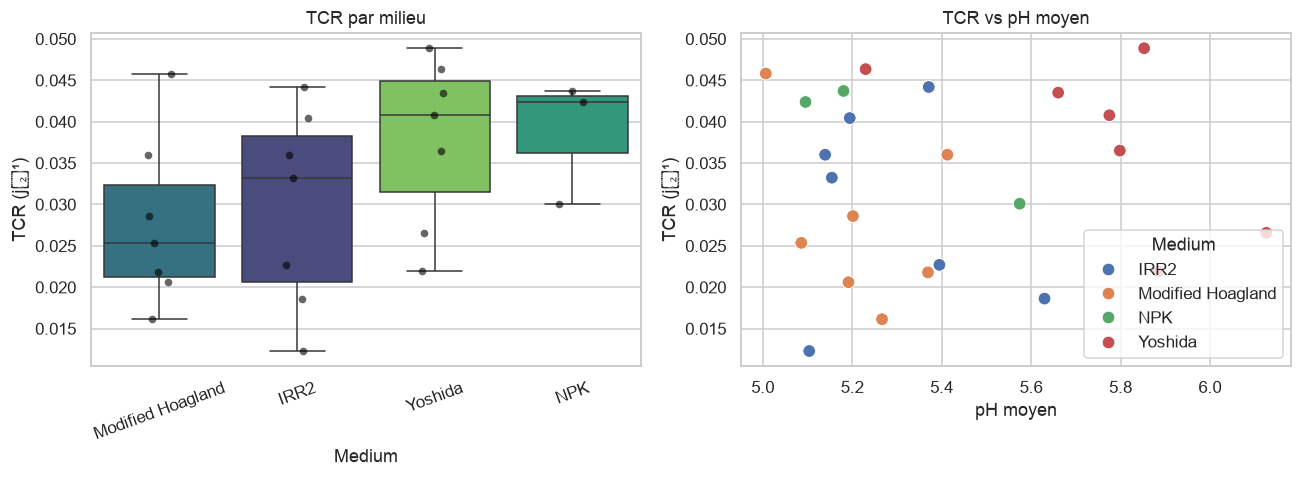

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Ordonne les milieux par TCR médian croissant (lecture facilitée)
order = bac_feat.groupby("Medium")["TCR"].median().sort_values().index
sns.boxplot(data=bac_feat, x="Medium", y="TCR", order=order, hue="Medium",
            legend=False, ax=ax[0], palette="viridis")
sns.stripplot(data=bac_feat, x="Medium", y="TCR", order=order, ax=ax[0],
              color="black", size=5, alpha=.6)   # points individuels
ax[0].set_title("TCR par milieu"); ax[0].set_ylabel("TCR (j⁻¹)")
ax[0].tick_params(axis="x", rotation=20)

sns.scatterplot(data=bac_feat, x="pH_mean", y="TCR", hue="Medium", s=70, ax=ax[1])
ax[1].set_title("TCR vs pH moyen"); ax[1].set_xlabel("pH moyen"); ax[1].set_ylabel("TCR (j⁻¹)")
plt.tight_layout(); savefig("01_eda.png"); plt.show()

#### Comment lire la figure 1 (EDA) — insights attendus

**Boxplot TCR par milieu (gauche)**
- La **boîte** = quartiles (Q1–Q3), la **ligne** = médiane, les **moustaches** = étendue, les
  **points noirs** = bacs individuels.
- *À regarder :* l'ordre des médianes indique quel milieu favorise le plus la croissance. Un
  chevauchement marqué des boîtes entre milieux annonce que les différences seront difficiles à
  distinguer statistiquement (et à apprendre pour le modèle).
- *Signal de dispersion :* une boîte « haute » (grande étendue intra-milieu) signale une forte
  variabilité biologique entre répétitions — c'est précisément ce qui plafonne la performance
  prédictive (voir section 5).

**Nuage TCR vs pH moyen (droite)**
- *À regarder :* une tendance (nuage incliné) suggérerait un lien pH→croissance ; un nuage diffus
  indique l'absence de relation linéaire simple. La couleur (milieu) permet de voir si le pH ne
  fait que séparer les milieux plutôt que d'expliquer la croissance en soi.

> Ces graphiques sont **descriptifs** : ils orientent l'interprétation mais ne testent rien
> (les tests statistiques relèvent de l'ANOVA, hors de ce notebook).

## 5. Benchmark des modèles par LOOCV

### Modèles et hyperparamètres (et pourquoi ces valeurs)

| Modèle | Hyperparamètres | Justification |
|---|---|---|
| **Régression linéaire** | (aucun) | Référence interprétable, sans réglage. |
| **Ridge** | `alpha=10.0` | Régularisation L2 forte : pénalise les grands coefficients pour limiter le surajustement à n faible. α élevé = régularisation marquée, adaptée quand peu d'observations. |
| **Random Forest** | `n_estimators=300`, `max_depth=2`, `min_samples_leaf=3` | Arbres **très peu profonds** (prof. 2) et feuilles d'au moins 3 bacs → contraint fortement la complexité pour éviter le surajustement. 300 arbres = stabilité de la moyenne. |
| **XGBoost** | `n_estimators=200`, `max_depth=2`, `learning_rate=0.05`, `reg_lambda=5.0`, `reg_alpha=1.0` | Profondeur 2 + faible taux d'apprentissage (0.05) + régularisation L2 (λ=5) et L1 (α=1) → modèle volontairement bridé, cohérent avec le petit échantillon. |

Tous les modèles stochastiques reçoivent `random_state=RANDOM_STATE` (reproductibilité).

### Standardisation (pipeline)

Les modèles **linéaires et Ridge** sont enveloppés dans un `make_pipeline(StandardScaler(), …)` :
le `StandardScaler` centre-réduit chaque variable (moyenne 0, écart-type 1). C'est **indispensable
pour Ridge** (la pénalité L2 dépend de l'échelle des variables) et garantit que la régularisation
traite toutes les features équitablement. Les modèles à base d'arbres (RF, XGBoost) sont insensibles
à l'échelle → pas de standardisation nécessaire.

### Mécanique de la LOOCV

`LeaveOneOut` génère n=24 partitions : à chaque tour, **1 bac sert de test** et les 23 autres
d'entraînement. On prédit le bac laissé de côté, puis on agrège les 24 prédictions hors-échantillon.
C'est l'estimation de généralisation la plus exigeante possible à cette taille — chaque bac est
prédit sans jamais avoir participé à l'entraînement de sa propre prédiction.

### Métriques

- **RMSE** (racine de l'erreur quadratique moyenne) : pénalise davantage les grosses erreurs.
- **MAE** (erreur absolue moyenne) : interprétation directe en unités de TCR.
- (R² volontairement écarté : non requis par le mémoire.)

In [8]:
def make_models():
    """Définit les 4 modèles avec hyperparamètres régularisés (cf. tableau ci-dessus)."""
    return {
        # Référence interprétable, sans hyperparamètre
        "Régression linéaire": make_pipeline(StandardScaler(), LinearRegression()),
        # Régularisation L2 forte (alpha=10) pour limiter le surajustement à faible n
        "Ridge":               make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
        # Forêt bridée : arbres peu profonds (2), feuilles >=3 bacs, 300 arbres pour la stabilité
        "Random Forest":       RandomForestRegressor(
            n_estimators=300, max_depth=2, min_samples_leaf=3,
            random_state=RANDOM_STATE),
        # Boosting bridé : profondeur 2, apprentissage lent (0.05), régularisations L2 et L1
        "XGBoost":             xgb.XGBRegressor(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            reg_lambda=5.0, reg_alpha=1.0, random_state=RANDOM_STATE),
    }

def loocv_eval(model, X, y):
    """Validation Leave-One-Out : retourne les prédictions hors-échantillon des n bacs."""
    loo = LeaveOneOut()
    preds = np.empty(len(y))
    truth = y.to_numpy()
    Xv = X.to_numpy()
    for train_idx, test_idx in loo.split(Xv):
        model.fit(Xv[train_idx], truth[train_idx])      # entraîne sur 23 bacs
        preds[test_idx] = model.predict(Xv[test_idx])   # prédit le bac exclu
    return preds

results, preds_store = [], {}
for name, model in make_models().items():
    preds = loocv_eval(model, X, y)
    preds_store[name] = preds
    results.append({"Modèle": name,
                    "RMSE": np.sqrt(mean_squared_error(y, preds)),
                    "MAE": mean_absolute_error(y, preds)})

# Tri par RMSE croissant + sauvegarde
res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
res_df.to_csv(OUTDIR / "model_comparison.csv", index=False)
res_df.round(5)

,Modèle,RMSE,MAE
0,Ridge,0.01094,0.00947
1,Régression linéaire,0.01098,0.00840
2,XGBoost,0.01113,0.00991
3,Random Forest,0.01178,0.01017


### Visualisation du benchmark

- **Barres** : RMSE par modèle. La **ligne rouge** est la baseline = erreur obtenue en prédisant
  simplement le TCR moyen pour tous les bacs. Un modèle n'apporte de valeur que s'il passe **à
  gauche** de cette ligne.
- **Observé vs prédit** (meilleur modèle) : chaque point = un bac ; la diagonale en pointillés est
  la prédiction parfaite. Plus les points y sont proches, meilleure est la prédiction.
- Figure : `outputs/02_benchmark_loocv.png`.

/var/folders/bg/fx2w93353qg5_7rlg3ckt4s00000gn/T/ipykernel_5344/3539938779.py:17: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout(); savefig("02_benchmark_loocv.png"); plt.show()
/var/folders/bg/fx2w93353qg5_7rlg3ckt4s00000gn/T/ipykernel_5344/2318939268.py:33: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(OUTDIR / name, bbox_inches="tight", dpi=150)


Figure enregistrée : ../outputs/02_benchmark_loocv.png


/Users/baha/PycharmProjects/Azolla-growth/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


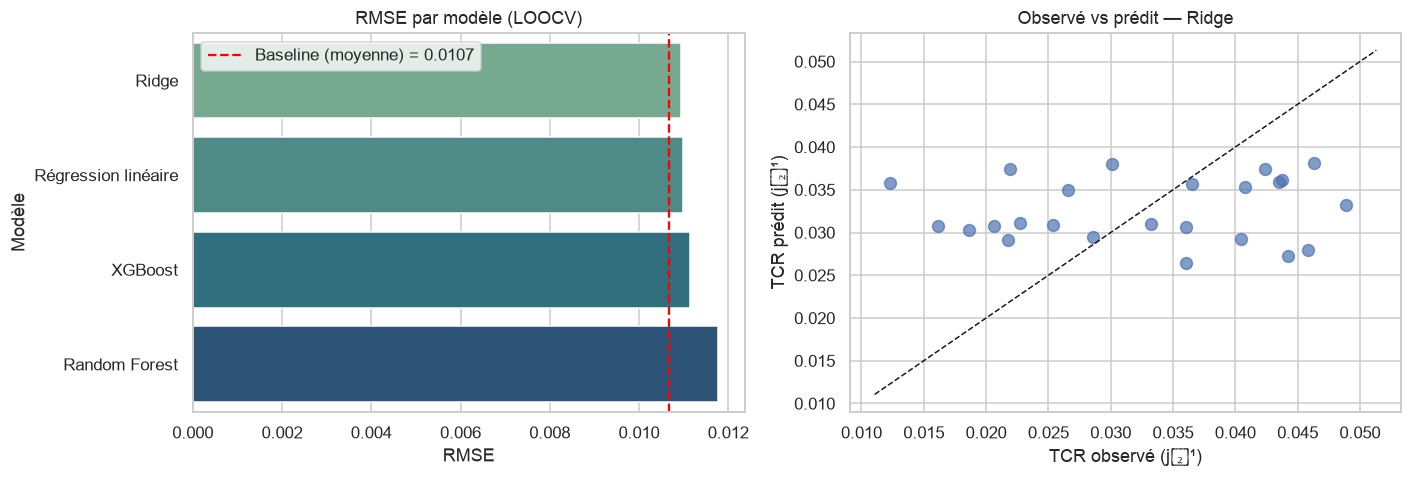

Meilleur modèle (RMSE) : Ridge


In [9]:
# Baseline : prédire la moyenne globale du TCR (modèle « naïf » de référence)
baseline_rmse = np.sqrt(mean_squared_error(y, np.full_like(y, y.mean())))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=res_df, x="RMSE", y="Modèle", hue="Modèle", legend=False,
            ax=ax[0], palette="crest")
ax[0].axvline(baseline_rmse, ls="--", color="red",
              label=f"Baseline (moyenne) = {baseline_rmse:.4f}")
ax[0].set_title("RMSE par modèle (LOOCV)"); ax[0].legend()

best = res_df.iloc[0]["Modèle"]               # meilleur modèle = RMSE la plus faible
ax[1].scatter(y, preds_store[best], s=60, alpha=.7)
lims = [y.min()*.9, y.max()*1.05]
ax[1].plot(lims, lims, "k--", lw=1)           # diagonale = prédiction parfaite
ax[1].set_xlabel("TCR observé (j⁻¹)"); ax[1].set_ylabel("TCR prédit (j⁻¹)")
ax[1].set_title(f"Observé vs prédit — {best}")
plt.tight_layout(); savefig("02_benchmark_loocv.png"); plt.show()
print("Meilleur modèle (RMSE) :", best)

#### Comment lire la figure 2 (benchmark) — insights attendus

**Barres RMSE + ligne baseline (gauche)**
- *Insight clé :* un modèle n'est utile que si sa barre est **à gauche** de la ligne rouge
  (baseline = prédire la moyenne). Une barre à droite signifie qu'il fait **moins bien que ne rien
  modéliser**.
- *Comparaison de complexité :* si les modèles simples (linéaire, Ridge) battent ou égalent les
  modèles complexes (RF, XGBoost), cela confirme le **principe de parcimonie** — à petit n, la
  complexité n'apporte rien, voire surajuste. C'est un résultat attendu et défendable ici.

**Observé vs prédit (droite)**
- *Insight clé :* les points doivent se rapprocher de la **diagonale**. Un nuage horizontal (le
  modèle prédit ~la même valeur quel que soit le bac réel) révèle que le modèle se rabat sur la
  moyenne → faible pouvoir prédictif.
- *Diagnostic :* des écarts systématiques (points d'un milieu tous au-dessus/au-dessous) signalent
  un biais par groupe.

> À cette taille d'échantillon et avec 4 profils de milieu, on **s'attend** à des RMSE proches de
> la baseline : à interpréter comme la limite intrinsèque de prédictibilité, pas comme un échec.

## 6. Importance des variables (modèle retenu) — exploratoire

Le meilleur modèle est **réentraîné sur l'ensemble des 24 bacs** (pas en LOOCV ici : on veut un
modèle final unique pour expliquer ses décisions), puis on calcule l'importance des variables :

- **SHAP** (SHapley Additive exPlanations) si la librairie est disponible :
  - `TreeExplainer` pour Random Forest / XGBoost (exact pour les modèles à arbres),
  - `LinearExplainer` pour les modèles linéaires (sur données standardisées).
- **Repli** si SHAP indisponible : importances natives (arbres) ou valeur absolue des coefficients
  (modèles linéaires).

Sorties : `outputs/03_*.png` et `outputs/feature_importance.csv`.

> Rappel : avec seulement 4 profils de milieu, l'importance reflète surtout des écarts entre
> groupes → interprétation **exploratoire**, pas causale.

Figure enregistrée : ../outputs/03_shap_summary.png


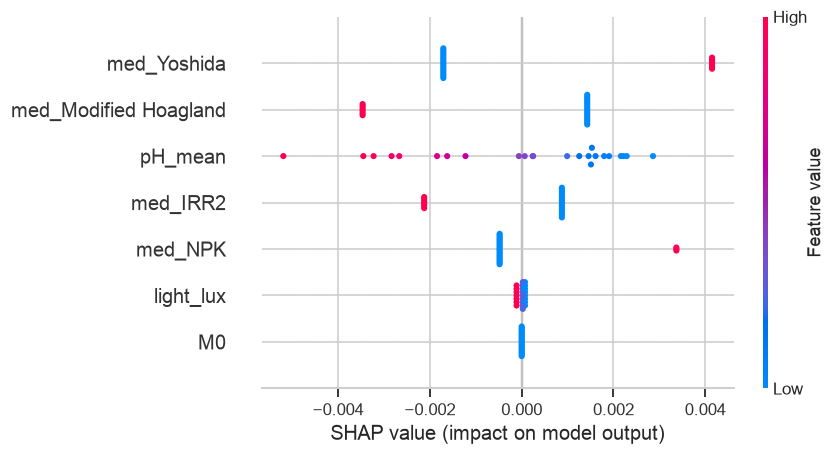

,feature,mean_abs_shap
3,med_Yoshida,0.002420
1,med_Modified Hoagland,0.002022
5,pH_mean,0.001844
0,med_IRR2,0.001240
2,med_NPK,0.000842
4,light_lux,0.000065
6,M0,0.000000


In [10]:
best_model = make_models()[best]
best_model.fit(X.to_numpy(), y.to_numpy())   # modèle final sur toutes les données

importance = None
try:
    import shap
    if best in ("Random Forest", "XGBoost"):
        sv = shap.TreeExplainer(best_model).shap_values(X)
    else:
        # Pour les pipelines linéaires : on explique l'estimateur final sur données standardisées
        Xs = StandardScaler().fit_transform(X)
        final_estimator = best_model.named_steps[list(best_model.named_steps)[-1]]
        sv = shap.LinearExplainer(final_estimator, Xs).shap_values(Xs)
    shap.summary_plot(sv, X, feature_names=feature_cols, show=False)
    savefig("03_shap_summary.png"); plt.show()
    importance = pd.DataFrame({"feature": feature_cols,
                               "mean_abs_shap": np.abs(sv).mean(axis=0)}
                              ).sort_values("mean_abs_shap", ascending=False)
except Exception as e:
    print("SHAP indisponible, repli sur importances natives :", e)
    if hasattr(best_model, "feature_importances_"):
        imp = best_model.feature_importances_          # arbres
    elif hasattr(best_model[-1], "coef_"):
        imp = np.abs(best_model[-1].coef_)             # linéaire : |coefficients|
    else:
        imp = np.zeros(len(feature_cols))
    importance = pd.DataFrame({"feature": feature_cols, "importance": imp}
                              ).sort_values("importance", ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=importance, x=importance.columns[1], y="feature",
                hue="feature", legend=False, palette="flare")
    plt.title(f"Importance des variables — {best}")
    plt.tight_layout(); savefig("03_feature_importance.png"); plt.show()

importance.to_csv(OUTDIR / "feature_importance.csv", index=False)
importance

#### Comment lire la figure 3 (importance des variables) — insights attendus

**Si SHAP (summary plot)**
- Chaque point = un bac ; **position horizontale** = impact de la variable sur la prédiction de ce
  bac (vers la droite = pousse le TCR prédit vers le haut). La **couleur** = valeur de la variable
  (rouge élevé, bleu faible).
- *Insight clé :* les variables sont classées de haut en bas par importance globale (|SHAP| moyen).
  La variable du haut est celle qui pèse le plus dans les prédictions.
- *Sens biologique :* si une concentration (ex. P) montre « valeur élevée → SHAP positif », le
  modèle associe plus de cet élément à une meilleure croissance. À confronter à la littérature.

**Si repli (barres d'importance)**
- Longueur de barre = importance relative (|coefficient| pour le linéaire, gain pour les arbres).
- *Insight clé :* identifie les 2–3 variables dominantes ; les variables à barre ~nulle (ex. `M0`
  constante) n'apportent rien, ce qui est attendu.

> ⚠️ En mode one-hot, les variables importantes seront des **indicatrices de milieu** — le modèle
> ne fait que séparer les groupes. L'intérêt biologique n'apparaît qu'après remplissage de
> `medium_composition.csv` (variables = vrais éléments N, P, K…).

## 7. Synthèse

- **Données :** 24 bacs, plan déséquilibré (3/7/7/7), `Feuil2` comme référence.
- **Cible :** TCR (Hunt, 1982). M0 constante (36 g).
- **Validation :** LOOCV ; métriques RMSE et MAE ; graine `RANDOM_STATE=42`.
- **Modèles :** du plus simple (linéaire) au plus complexe (XGBoost), tous fortement régularisés.
- **Sorties :** figures + tableaux dans `outputs/`.
- **À compléter :** renseigner `data/medium_composition.csv` (mmol/L) → remplace le one-hot par
  les vraies concentrations (rend SHAP biologiquement interprétable).

**Variables exclues :** humidité, photopériode (non mesurées par bac / constantes), TDS, salinité
(colinéaires à la CE). **Approche 2 (déplétion CE)** : non implémentée (CE mono-temporelle),
discutée théoriquement. Détails : `RESULTS_AND_LIMITATIONS.md`.